In [1]:
# Design a 20 ns two-photon transition from |0> to |2> in a transmon qubit.
# The optimization aims to:
#   - Maximize population transfer from |0> to |2> via a two-photon process,
#   - Minimize leakage to level |3>,
#   - Minimize the total pulse energy.
# The system is modeled with an anharmonicity of -200 MHz.
# Estimated script runtime: ~15 seconds.

# AUTHOR:
#     Leo Van Damme / Technical University of Munich, 2025

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from grape_scq import Transmon, StateTarget, OptimizationProblem, GrapeOptimizer, initial_guess

In [3]:
# Physical system and target: drive at the two-photon carrier nu_q + alpha/2
system = Transmon(
    n_levels=4,
    anharmonicity=-200e6,
    frequency=5e9,
    carrier_frequency=5e9 - 200e6/2,
)
target = StateTarget(initial=[1, 0, 0, 0], target=[0, 0, 1, 0])
problem = OptimizationProblem(system, target, n_steps=200, dt=0.1e-9, reference_amplitude=100e6)

In [4]:
# Initial pulse guess
pulse0 = initial_guess.random_symmetric_antisymmetric(problem)

In [5]:
# Optimize the pulse
optimizer = GrapeOptimizer(max_iter=1000, minimize_energy=True)
result = optimizer.optimize(problem, pulse0)

Compiling cost function... Done.
Pre-optimization = 10/10, cost (+ penalty) = -0.000000
GRAPE optimization result
  cost:      0.991442 -> -0.000000
  fidelity:  0.008558 -> 1.000000
  iterations: 1 (+ 324 pre-optimization)
  message:   CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH


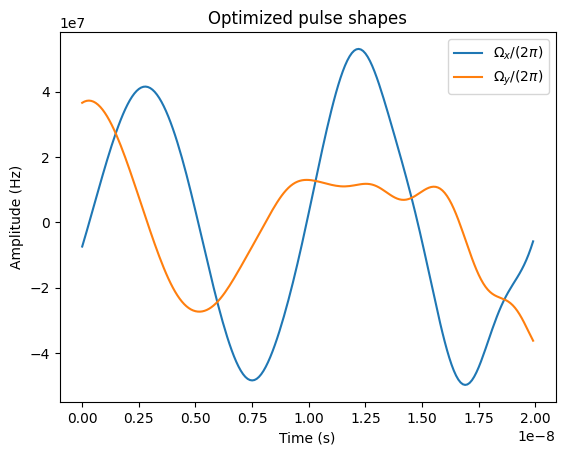

In [6]:
# Display in-phase and quadrature pulse components
result.plot_pulse(compare_to_initial=False)
plt.title("Optimized pulse shapes")
plt.show()

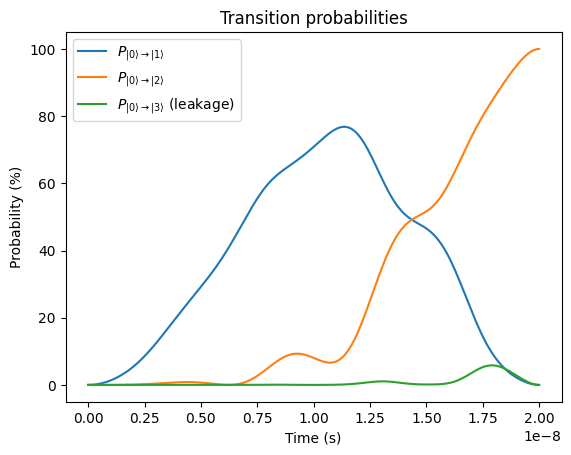

In [7]:
# Display transition probabilities
plt.figure()
plt.plot(problem.t, result.population(0, 1)*100, label=r'$P_{|0\rangle\rightarrow|1\rangle}$')
plt.plot(problem.t, result.population(0, 2)*100, label=r'$P_{|0\rangle\rightarrow|2\rangle}$')
plt.plot(problem.t, result.population(0, 3)*100, label=r'$P_{|0\rangle\rightarrow|3\rangle}$ (leakage)')
plt.xlabel('Time (s)')
plt.ylabel('Probability (%)')
plt.legend()
plt.title("Transition probabilities")
plt.show()